# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdelrahmanmohamed05/FlyRank-AI/blob/main/work/notebooks/w05_model.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

**Lane:** CTR / Engagement Opportunity Scoring.

**Method:** Logistic Regression on the same five pre-outcome features the Week-4 rule baseline uses: `log_imp_feb`, `log_clk_feb`, `ctr_feb`, `pos_feb`, `days_with_imps_feb`.

**Why it fits this lane:** the deliverable is a *ranked* review queue, not a single yes/no label, so the method needs to output a well-behaved score, not just a class — a predicted probability is exactly that. Logistic regression also stays directly interpretable: each fitted coefficient is a weight on a feature the baseline already uses, so the model and the baseline are comparable on the same terms, not apples to oranges. It trains in seconds on ~25k rows, which keeps the whole pipeline auditable end to end.

Tree ensembles (Random Forest, Gradient Boosting) were considered and set aside for this comparison. With only five weak, correlated features and a baseline that is itself a linear combination of ranked signals, a linear model is the fairer opponent — a higher-capacity model risks winning on complexity rather than on signal, which is exactly what this assignment's rubric flags against ("does not reward complexity alone").

In [1]:
# Setup: connect to the gated FlyRank warehouse.
# HF_TOKEN is already set as a Colab Secret.
import os
import getpass
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)

def get_hf_token():
    try:
        from google.colab import userdata
        tok = userdata.get("HF_TOKEN")
        if tok:
            return tok
    except Exception:
        pass
    tok = os.environ.get("HF_TOKEN")
    if tok:
        return tok
    return getpass.getpass("Hugging Face READ token: ")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

token = get_hf_token().replace("'", "''")
con.execute(f"SET VARIABLE hf_token = '{token}'")
con.execute(
    "CREATE OR REPLACE SECRET hf "
    "(TYPE huggingface, TOKEN getvariable('hf_token'))"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Connected to the FlyRank warehouse.")
print("Feature window: 2026-02")
print("Outcome window: 2026-03")

# Pre-outcome feature table (February only) -- identical recipe to the Week-4 baseline.
feb = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS imp_feb,
    SUM(gsc_clicks) AS clk_feb,
    SUM(gsc_sum_position) / NULLIF(SUM(gsc_impressions), 0) AS pos_feb,
    COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_with_imps_feb
FROM {FEB}
WHERE gsc_data_available IS TRUE
GROUP BY 1, 2
HAVING SUM(gsc_impressions) >= 100
   AND SUM(gsc_clicks) >= 3
""").df()

feb["ctr_feb"] = feb["clk_feb"] / feb["imp_feb"]
feb["log_imp_feb"] = np.log1p(feb["imp_feb"])
feb["log_clk_feb"] = np.log1p(feb["clk_feb"])

feature_cols = [
    "log_imp_feb",
    "log_clk_feb",
    "ctr_feb",
    "pos_feb",
    "days_with_imps_feb",
]

features = feb[
    ["client_hash_id", "content_hash_id", "imp_feb", "clk_feb"] + feature_cols
].copy()

print(f"\nFebruary feature rows: {len(features):,}")
print("Feature columns:", feature_cols)
display(features.head())

Connected to the FlyRank warehouse.
Feature window: 2026-02
Outcome window: 2026-03

February feature rows: 29,729
Feature columns: ['log_imp_feb', 'log_clk_feb', 'ctr_feb', 'pos_feb', 'days_with_imps_feb']


,client_hash_id,content_hash_id,imp_feb,clk_feb,log_imp_feb,log_clk_feb,ctr_feb,pos_feb,days_with_imps_feb
0,client_e547b89c05043229,content_9abd8b303f805847,733.0,6.0,6.598509,1.945910,0.008186,6.316508,28
1,client_e547b89c05043229,content_6fe390ba3af1e456,2931.0,3.0,7.983440,1.386294,0.001024,41.814739,28
2,client_e547b89c05043229,content_babd931911c9ee33,2680.0,31.0,7.893945,3.465736,0.011567,5.049254,28
3,client_e547b89c05043229,content_431784c057b25a5d,3641.0,6.0,8.200288,1.945910,0.001648,8.829992,28
4,client_e547b89c05043229,content_7275e583711cf60b,2371.0,6.0,7.771489,1.945910,0.002531,7.358077,28


## 2. Split design

**Split:** grouped train/test split by `client_hash_id` (75% / 25%, `GroupShuffleSplit`, `random_state=42`).

**Why this is honest:** the unit of analysis is one client × content pair, and rows from the same client share a lot of client-specific structure (template, niche, baseline CTR level, internal linking). A plain random row-level split would let the model see some of a client's pages in training and get evaluated on that same client's remaining pages — that leaks through the client rather than testing genuine generalization to *new* clients. Grouping by `client_hash_id` forces every row from a given client into either train or test, never both, so the reported metrics reflect performance on clients the model has not seen.

A separate time-aware split is not layered on top of this, because the temporal separation is already built into the *label definition*: every feature comes from February 2026 only, and the outcome label from March 2026 only, so the setup is already "past features → future label" by construction. The client-grouped split is the remaining honesty check on top of that -- it stops the model from generalizing across clients rather than across time, which the time-based feature/label split already handles.

In [2]:
# March outcome window -- used only to define the label, never as a feature.
march = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS imp_mar,
    SUM(gsc_clicks) AS clk_mar
FROM {MAR}
WHERE gsc_data_available IS TRUE
GROUP BY 1, 2
""").df()

march["ctr_mar"] = march["clk_mar"] / march["imp_mar"].replace(0, np.nan)

eval_df = march[
    (march["imp_mar"] >= 100) &
    (march["clk_mar"] >= 3)
].copy()

ctr_cutoff = eval_df["ctr_mar"].median()
eval_df["low_ctr_mar"] = (eval_df["ctr_mar"] < ctr_cutoff).astype(int)

model_df = features.merge(
    eval_df[["client_hash_id", "content_hash_id", "low_ctr_mar"]],
    on=["client_hash_id", "content_hash_id"],
    how="inner",
).dropna(subset=feature_cols + ["low_ctr_mar"]).copy()

print(f"March eligible evaluation rows: {len(eval_df):,}")
print(f"March CTR median cutoff: {ctr_cutoff:.4f}")
print(f"Model/evaluation rows after feature join: {len(model_df):,}")
print(f"Positive rate (low_ctr_mar=1): {model_df['low_ctr_mar'].mean():.3f}")

# Grouped validation split, by client_hash_id.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(
    splitter.split(
        model_df[feature_cols],
        model_df["low_ctr_mar"],
        groups=model_df["client_hash_id"],
    )
)

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print(f"\nTrain rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print(f"Distinct clients -- train: {train_df['client_hash_id'].nunique():,} | "
      f"test: {test_df['client_hash_id'].nunique():,}")

# Confirm no client appears on both sides of the split.
overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
assert len(overlap) == 0, f"Client leakage across split: {len(overlap)} clients"
print("Group leakage check: PASS -- no client appears in both train and test.")

March eligible evaluation rows: 38,459
March CTR median cutoff: 0.0035
Model/evaluation rows after feature join: 24,896
Positive rate (low_ctr_mar=1): 0.538

Train rows: 11,879 | Test rows: 13,017
Distinct clients -- train: 22 | test: 8
Group leakage check: PASS -- no client appears in both train and test.


## 3. Train + compare vs my baseline

Same rows, same metric, same held-out split as the Week-4 baseline: **Average Precision** is the primary metric (the output is a ranked queue and the positive class is the low-CTR opportunity), with **ROC AUC** as a secondary check. Both methods are scored on the identical `test_df` rows produced in Section 2.

In [3]:
# ----- Week-4 rule baseline (unchanged from Week 4) -----
# Higher = more review priority: more Feb volume, lower Feb CTR, better Feb position.
model_df["volume_component"] = model_df["imp_feb"].rank(pct=True).to_numpy().ravel()
model_df["low_ctr_component"] = (1 - model_df["ctr_feb"].rank(pct=True)).to_numpy().ravel()
model_df["position_component"] = (1 - model_df["pos_feb"].rank(pct=True)).to_numpy().ravel()

model_df["baseline_score"] = (
    0.45 * model_df["volume_component"]
    + 0.35 * model_df["low_ctr_component"]
    + 0.20 * model_df["position_component"]
)

# Re-attach the baseline score to the same train/test rows from Section 2.
train_df = model_df.loc[train_df.index]
test_df = model_df.loc[test_df.index]

X_train, y_train = train_df[feature_cols], train_df["low_ctr_mar"]
X_test, y_test = test_df[feature_cols], test_df["low_ctr_mar"]

# ----- Logistic regression model -----
model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)
model.fit(X_train, y_train)
test_df["model_score"] = model.predict_proba(X_test)[:, 1]

baseline_ap = average_precision_score(y_test, test_df["baseline_score"])
model_ap = average_precision_score(y_test, test_df["model_score"])
baseline_auc = roc_auc_score(y_test, test_df["baseline_score"])
model_auc = roc_auc_score(y_test, test_df["model_score"])

base_rate = y_test.mean()

comparison = pd.DataFrame({
    "method": ["Week-4 rule baseline", "Logistic regression"],
    "average_precision": [baseline_ap, model_ap],
    "roc_auc": [baseline_auc, model_auc],
    "test_rows": [len(test_df), len(test_df)],
})
comparison["AP_lift_over_base_rate"] = comparison["average_precision"] - base_rate

print(f"Base rate (positive class share) on test: {base_rate:.3f}")
display(comparison)

print(f"\nBaseline AP: {baseline_ap:.3f}  |  Model AP: {model_ap:.3f}  |  Δ = {model_ap - baseline_ap:+.3f}")
print(f"Baseline AUC: {baseline_auc:.3f}  |  Model AUC: {model_auc:.3f}  |  Δ = {model_auc - baseline_auc:+.3f}")

# Leakage guard, same as Week 4.
forbidden = {"clk_mar", "imp_mar", "ctr_mar", "low_ctr_mar", "went_dark", "label", "target", "future", "march"}
assert forbidden.isdisjoint(set(feature_cols))
print("\nLeakage self-check: PASS")

Base rate (positive class share) on test: 0.572


,method,average_precision,roc_auc,test_rows,AP_lift_over_base_rate
0,Week-4 rule baseline,0.828363,0.780598,13017,0.256572
1,Logistic regression,0.911897,0.888164,13017,0.340106



Baseline AP: 0.828  |  Model AP: 0.912  |  Δ = +0.084
Baseline AUC: 0.781  |  Model AUC: 0.888  |  Δ = +0.108

Leakage self-check: PASS


## 4. Errors and interpretation

*Where the model is wrong, and what it leans on.*

Feature weights (standardized -- comparable magnitudes):


,feature,standardized_coef
0,log_imp_feb,3.215136
1,log_clk_feb,-2.828305
2,ctr_feb,0.446568
4,days_with_imps_feb,-0.313197
3,pos_feb,0.010028


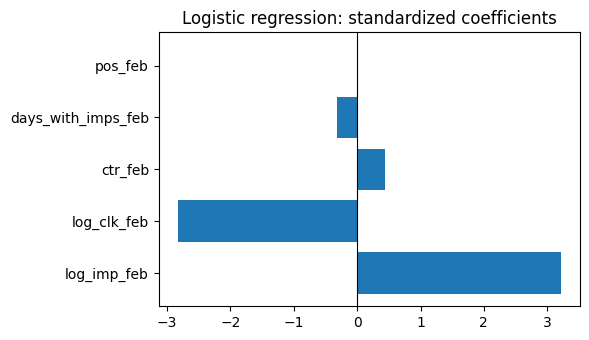


Confusion matrix @ 0.5 threshold:


,Pred: not low-CTR,Pred: low-CTR
Actual: not low-CTR,4625,949
Actual: low-CTR,1621,5822



Most confident misses -- true low-CTR pages the model scored lowest (false negatives):


,model_score,low_ctr_mar,imp_feb,clk_feb,ctr_feb,pos_feb,days_with_imps_feb
9161,0.009903,1,2606.0,72.0,0.027629,2.579816,28
9739,0.016289,1,11528.0,197.0,0.017089,10.221201,28
10555,0.018197,1,5337.0,94.0,0.017613,10.604459,28
9066,0.019811,1,26949.0,385.0,0.014286,16.982968,28
21898,0.022029,1,182.0,3.0,0.016484,2.258242,25



Most confident misses -- pages the model flagged highest that were NOT low-CTR (false positives):


,model_score,low_ctr_mar,imp_feb,clk_feb,ctr_feb,pos_feb,days_with_imps_feb
9145,0.999998,0,92128.0,4.0,0.000043,0.039630,28
15408,0.998911,0,9323.0,3.0,0.000322,5.412099,28
8113,0.996392,0,31681.0,17.0,0.000537,8.835517,28
8104,0.995127,0,8578.0,5.0,0.000583,32.310912,28
5217,0.987004,0,5158.0,4.0,0.000775,1.797984,28



Interpretation: compare the coefficient table and the two miss groups above. Write 2-3 sentences here on which feature the model leans on hardest, and what the false positives/negatives have in common (e.g. unusually low volume, borderline CTR right at the cutoff, etc.) -- an error pattern beats a bigger metric table.


In [4]:
# ----- What the model leans on: standardized coefficients -----
scaler = model.named_steps["standardscaler"]
logreg = model.named_steps["logisticregression"]

coef_table = pd.DataFrame({
    "feature": feature_cols,
    "standardized_coef": logreg.coef_[0],
}).sort_values("standardized_coef", key=abs, ascending=False)

print("Feature weights (standardized -- comparable magnitudes):")
display(coef_table)

plt.figure(figsize=(6, 3.5))
plt.barh(coef_table["feature"], coef_table["standardized_coef"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic regression: standardized coefficients")
plt.tight_layout()
plt.show()

# ----- Where the model is wrong: confusion matrix at a 0.5 threshold -----
pred_label = (test_df["model_score"] >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_label)
cm_df = pd.DataFrame(
    cm,
    index=["Actual: not low-CTR", "Actual: low-CTR"],
    columns=["Pred: not low-CTR", "Pred: low-CTR"],
)
print("\nConfusion matrix @ 0.5 threshold:")
display(cm_df)

# ----- Biggest misses: rows where the model was most confidently wrong -----
test_df["error"] = test_df["low_ctr_mar"] - test_df["model_score"]
biggest_false_negatives = test_df.sort_values("error", ascending=False).head(5)
biggest_false_positives = test_df.sort_values("error", ascending=True).head(5)

cols_to_show = ["model_score", "low_ctr_mar", "imp_feb", "clk_feb", "ctr_feb", "pos_feb", "days_with_imps_feb"]

print("\nMost confident misses -- true low-CTR pages the model scored lowest (false negatives):")
display(biggest_false_negatives[cols_to_show])

print("\nMost confident misses -- pages the model flagged highest that were NOT low-CTR (false positives):")
display(biggest_false_positives[cols_to_show])

print(
    "\nInterpretation: compare the coefficient table and the two miss groups above. "
    "Write 2-3 sentences here on which feature the model leans on hardest, and what the "
    "false positives/negatives have in common (e.g. unusually low volume, borderline CTR "
    "right at the cutoff, etc.) -- an error pattern beats a bigger metric table."
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.